# ECF4 - Fake News

In [74]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from copy import deepcopy

import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# Chemins
PROJECT_DIR = Path("../").resolve()
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_FILE = DATA_DIR / "fake_or_real_news.csv"
DATA_CLEAN_FILE = DATA_DIR / "titles_clean.csv"

FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [44]:
# Configurations des graphiques
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

PALETTE = sns.color_palette("colorblind")

## Partie 1 — Chargement et exploration

### 1.1 Chargement et constitution du corpus de titres

In [45]:
def load_titles(filepath: Path) -> pd.DataFrame:
    def convert_label(label_str: str) -> int:
        if label_str.lower() == "fake":
            return 0
        elif label_str.lower() == "real":
            return 1
        else:
            return None

    if not filepath.exists():
        raise FileNotFoundError(f"Fichier introuvable: path={str(filepath)}")

    df = pd.read_csv(filepath)
    length_df = len(df)
    print(
        f"Dimensions du jeu de données chargé : {df.shape[0]} lignes et {df.shape[1]} colonnes"
    )

    df = df[["title", "label"]]
    df = df.rename(columns={"title": "text"})
    df["label"] = df["label"].apply(convert_label)
    df = df.dropna()
    mask = (
        (df["text"].str.strip() != "")
        & (df["text"].str.strip().str.lower() != "null")
        & (df["text"].str.strip().str.lower() != "none")
    )
    df = df[mask]
    length_df_processed = len(df)
    print(
        f"Dimensions du jeu de données après traitement : {df.shape[0]} lignes et {df.shape[1]} colonnes"
    )
    print(f"Nombre de lignes supprimées : {length_df - length_df_processed}")

    df.to_csv(DATA_CLEAN_FILE, index=False)
    return df


df = load_titles(DATA_FILE)
df.head()

Dimensions du jeu de données chargé : 6335 lignes et 4 colonnes
Dimensions du jeu de données après traitement : 6335 lignes et 2 colonnes
Nombre de lignes supprimées : 0


,text,label
0,You Can Smell Hillary’s Fear,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,0
2,Kerry to go to Paris in gesture of sympathy,1
3,Bernie supporters on Twitter erupt in anger ag...,0
4,The Battle of New York: Why This Primary Matters,1


### 1.2 Analyse exploratoire

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_17536\3836955107.py:6: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  barplot = sns.barplot(


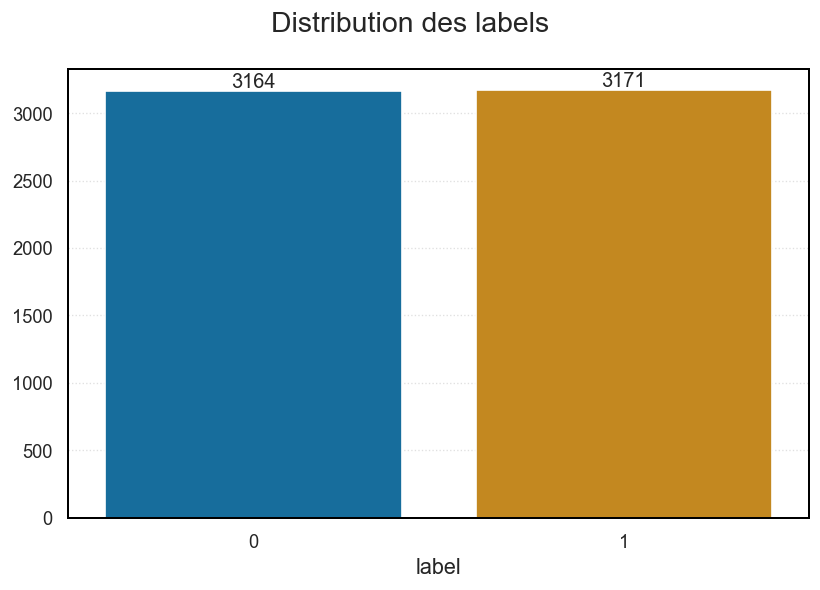

In [ ]:
def create_barplot(
    ax: plt.Axes, df: pd.DataFrame, column: str, rotation: int = 0
) -> None:
    value_counts = df[column].value_counts()

    barplot = sns.barplot(
        x=value_counts.index,
        y=value_counts.values,
        palette=PALETTE,
        hue=value_counts.index,
        legend=False,
        ax=ax,
    )

    for container in barplot.containers:
        barplot.bar_label(container)

    if rotation:
        ax.tick_params(axis="x", rotation=rotation)


fig, ax = plt.subplots(1, 1, figsize=(7, 5))

fig.suptitle("Distribution des labels", fontsize=17)

create_barplot(ax=ax, df=df, column="label", rotation=0)

plt.tight_layout()
plt.savefig((FIGURE_DIR / "01_label_distrubution.png").as_posix())
plt.show()

* Les classes sont équilibrée, aucune stratégie de rééquilibrage n'est à prévoir.
* Si les classes avaient été déséquilibrées, on aurait pu mettre en place une stratégie d'oversampling consistant à ajouter des données dans la classe minoritaire. Ces nouvelles données pouvant être artificielles ou une duplication des données existantes. Un autre stratégie possible consiste à pondérer la classes minoritaire avec un poid plus important lors de la phase d'entraînement d'un modèle de sorte qu'un classement érroné d'un classe minoritaire soit plus lourdement pénalisé.

In [48]:
df_eda = df.copy()
df_eda["tokens"] = df_eda["text"].str.split()
df_eda["length"] = df_eda["tokens"].apply(lambda list_tokens: len(list_tokens))

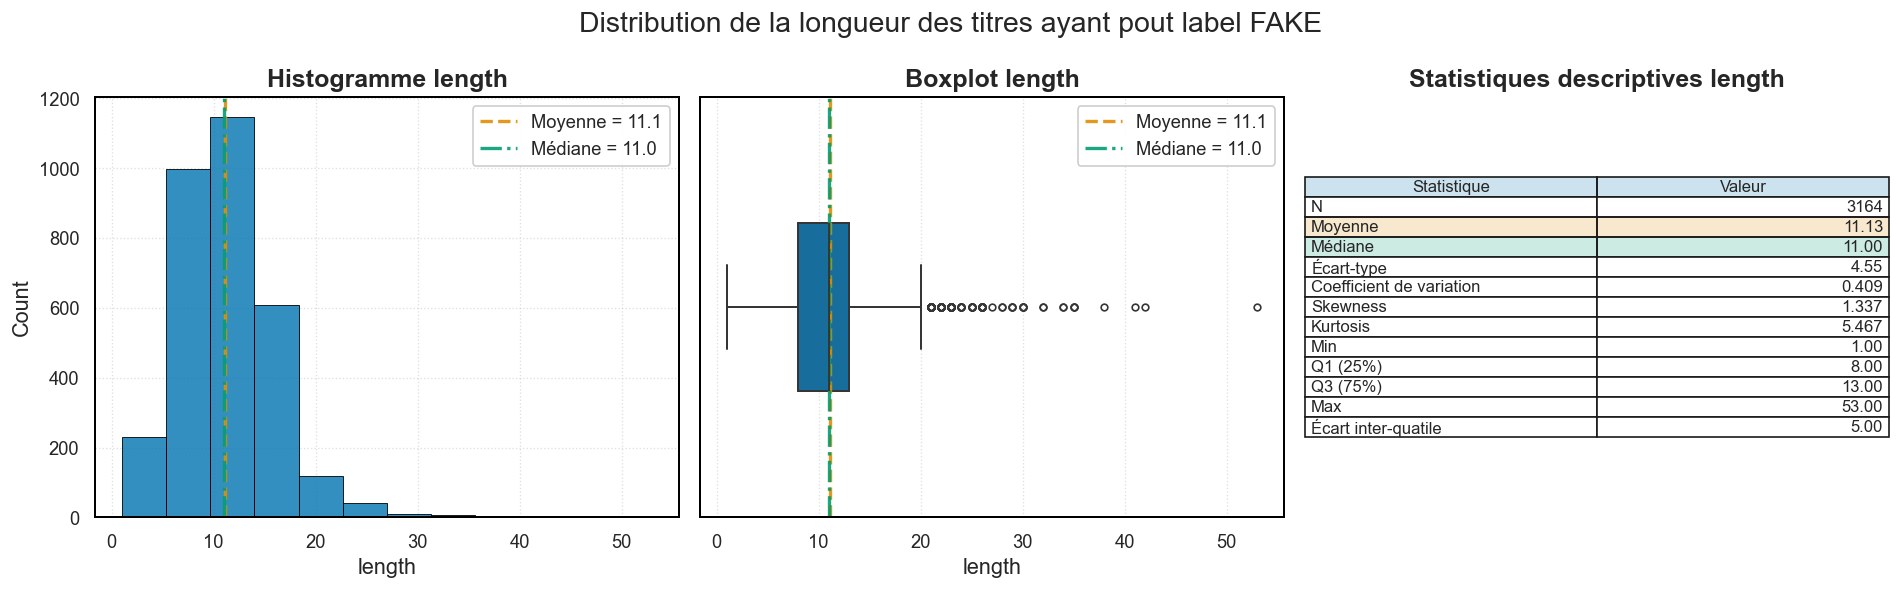

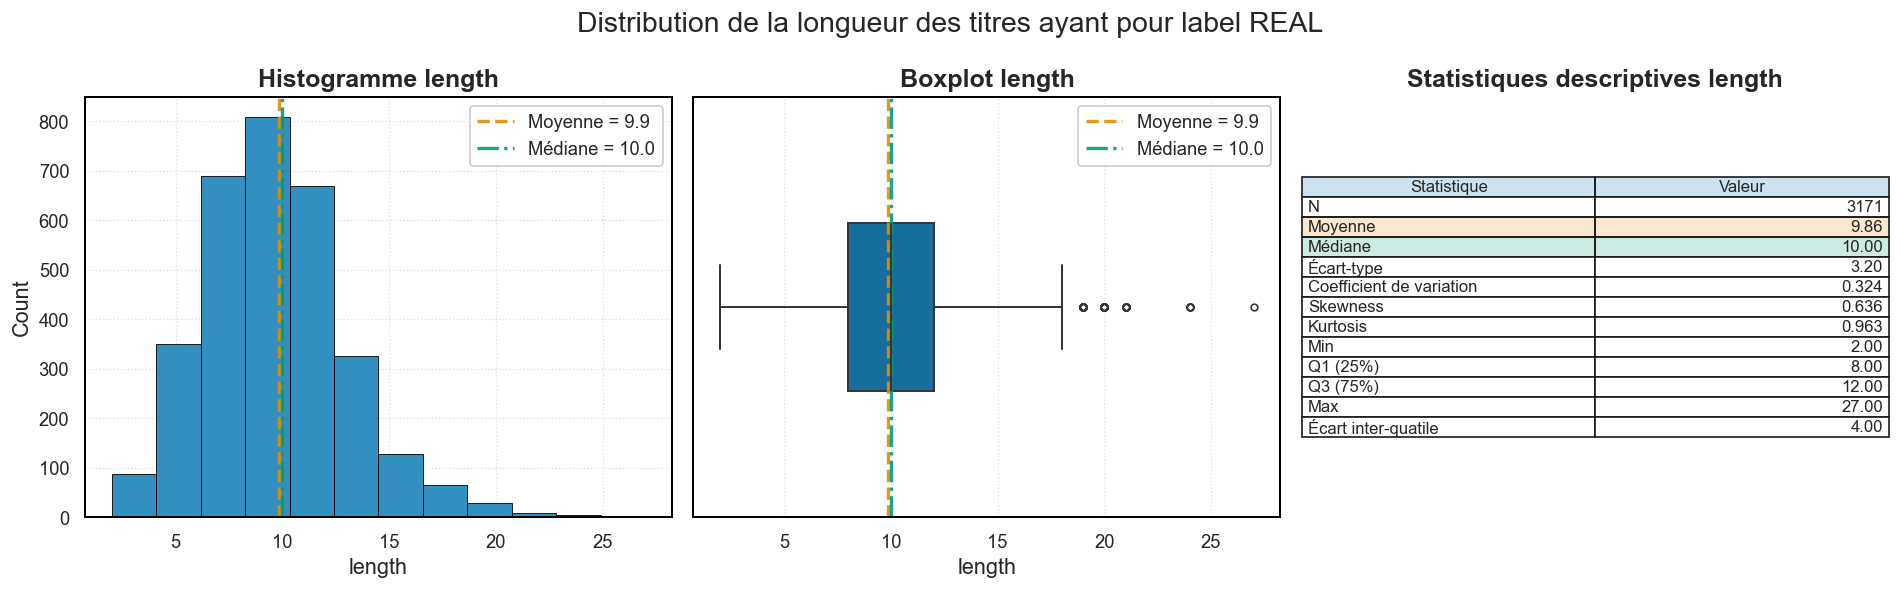

In [ ]:
def create_histplot(ax: plt.Axes, df: pd.DataFrame, column: str) -> None:
    values = df[column].dropna()

    sns.histplot(
        x=values,
        bins=int(1 + np.log2(len(values))),
        color=PALETTE[0],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
        ax=ax,
    )

    mean_column = values.mean()
    median_column = values.median()

    ax.axvline(
        mean_column,
        color=PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axvline(
        median_column,
        color=PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.1f}",
    )

    ax.set_title(f"Histogramme {column}")
    ax.legend(frameon=True)


def create_boxplot(ax: plt.Axes, df: pd.DataFrame, column: str) -> None:
    values = df[column].dropna()

    sns.boxplot(
        x=values,
        ax=ax,
        color=PALETTE[0],
        width=0.4,
        fliersize=4,
        linewidth=1.2,
    )

    mean_val = values.mean()
    median_val = values.median()

    ax.axvline(
        mean_val,
        color=PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_val:.1f}",
    )

    ax.axvline(
        median_val,
        color=PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_val:.1f}",
    )

    ax.set_title(f"Boxplot {column}")
    ax.legend(frameon=True)


def create_stats_panel(ax: plt.Axes, df: pd.DataFrame, column: str) -> None:
    values = df[column].dropna()

    mean_val = values.mean()
    std_val = values.std()
    cv = std_val / mean_val if mean_val != 0 else np.nan
    skew = values.skew()
    kurt = values.kurtosis()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    stats_data = [
        ["N", f"{len(values)}"],
        ["Moyenne", f"{mean_val:.2f}"],
        ["Médiane", f"{values.median():.2f}"],
        ["Écart-type", f"{std_val:.2f}"],
        ["Coefficient de variation", f"{cv:.3f}"],
        ["Skewness", f"{skew:.3f}"],
        ["Kurtosis", f"{kurt:.3f}"],
        ["Min", f"{values.min():.2f}"],
        ["Q1 (25%)", f"{q1:.2f}"],
        ["Q3 (75%)", f"{q3:.2f}"],
        ["Max", f"{values.max():.2f}"],
        ["Écart inter-quatile", f"{q3 - q1:.2f}"],
    ]

    table = ax.table(
        cellText=stats_data,
        colLabels=["Statistique", "Valeur"],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )

    ax.set_title(f"Statistiques descriptives {column}")

    # Style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.1)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(PALETTE[0] + (0.2,))
        else:
            cell.PAD = 0.02
            if col == 0:
                cell.get_text().set_ha("left")
        if row == 2:
            cell.set_facecolor(PALETTE[1] + (0.2,))
        if row == 3:
            cell.set_facecolor(PALETTE[2] + (0.2,))

    ax.set_axis_off()


df_eda_fake = df_eda[df_eda["label"] == 0]
df_eda_real = df_eda[df_eda["label"] == 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    "Distribution de la longueur des titres ayant pout label FAKE", fontsize=17
)

create_histplot(ax=axes[0], df=df_eda_fake, column="length")
create_boxplot(ax=axes[1], df=df_eda_fake, column="length")
create_stats_panel(ax=axes[2], df=df_eda_fake, column="length")

plt.tight_layout()
plt.savefig((FIGURE_DIR / "02_length_text_distribution_label_fake.png").as_posix())
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    "Distribution de la longueur des titres ayant pour label REAL", fontsize=17
)

create_histplot(ax=axes[0], df=df_eda_real, column="length")
create_boxplot(ax=axes[1], df=df_eda_real, column="length")
create_stats_panel(ax=axes[2], df=df_eda_real, column="length")

plt.tight_layout()
plt.savefig((FIGURE_DIR / "03_length_text_distribution_label_real.png").as_posix())
plt.show()

Comparaison des distribution des longueurs des titres par label `FAKE` ou `REAL`:
* Les titres `FAKE` sont légèrement plus longs en moyenne (environ 1 mot supplémentaire), mais l’écart reste modéré.
* Les titres `FAKE` présentent une variabilité plus élevée avec un écrat-type, un coefficient de variation et écart inter-quartile plus élevè. De plus, on observe une dispersion plus large dans l’histogramme et un boxplot avec davantage d’outliers.
* La distribution des titre `FAKE` est asymétrique positive (skewness 1.33) et leptokurtique (kurtosis 5.47)n tandis que la distribution des titre `REAL` est proche de la normale. Les titres `FAKE` montrent une queue de distribution à droite plus lourde, avec des titres très longs (jusqu’à 53 mots), contrairement aux titres `REAL` (jusqu'à 27 mots).
* Les titre `FAKE` présentent beaucoup d'outliers comparé aux titre `REAL`, ce qui suggère que les contenus `FAKE` exploitent parfois des titres longs.

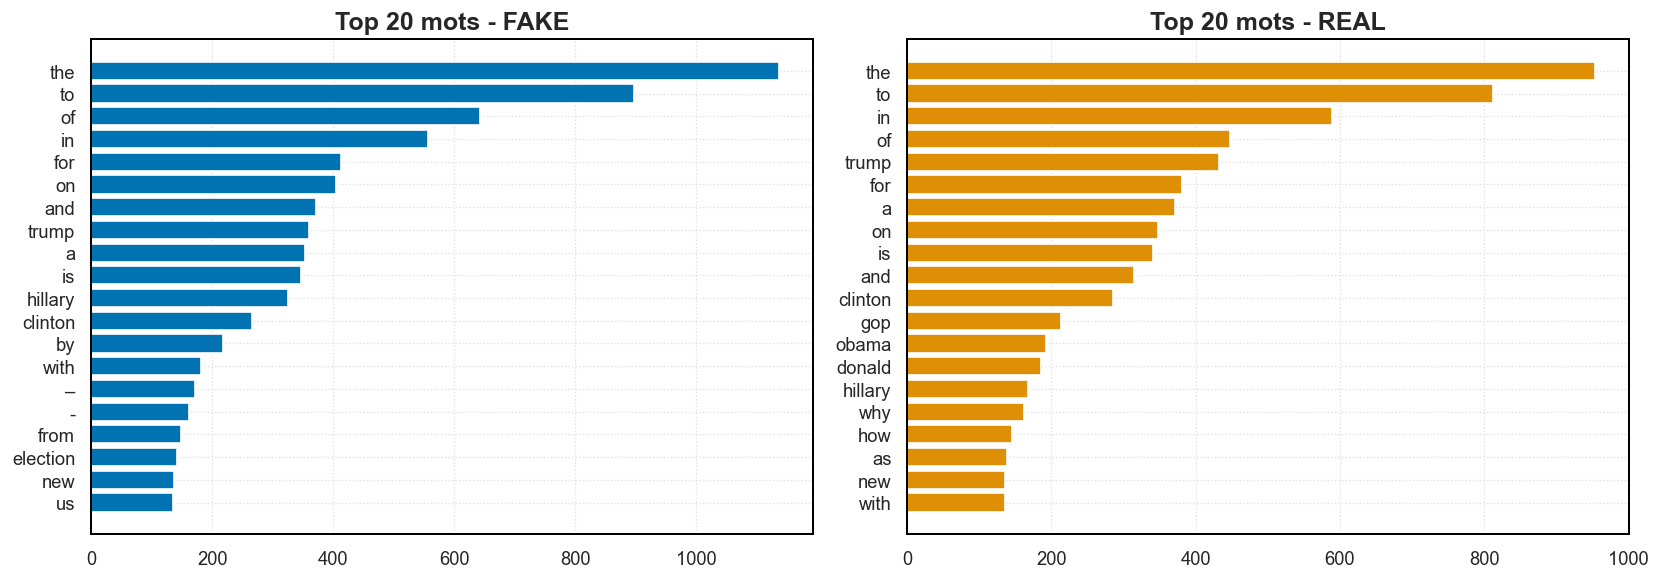

In [63]:
tokens_fake_flat = df_eda_fake["text"].str.lower().str.cat(sep=" ").split()
tokens_real_flat = df_eda_real["text"].str.lower().str.cat(sep=" ").split()

counter_fake = Counter(tokens_fake_flat)
counter_real = Counter(tokens_real_flat)

top20_fake = counter_fake.most_common(20)
top20_real = counter_real.most_common(20)

words_fake, counts_fake = zip(*top20_fake)
words_real, counts_real = zip(*top20_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(words_fake, counts_fake, color=PALETTE[0])
axes[0].set_title("Top 20 mots - FAKE")
axes[0].invert_yaxis()

axes[1].barh(words_real, counts_real, color=PALETTE[1])
axes[1].set_title("Top 20 mots - REAL")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig((FIGURE_DIR / "04_tokens_distribution_per_labels.png").as_posix())
plt.show()

In [ ]:
unique_tokens_fake = set(tokens_fake_flat)
unique_tokens_real = set(tokens_real_flat)

unique_tokens_union = unique_tokens_fake | unique_tokens_real
unique_tokens_intersection = unique_tokens_fake & unique_tokens_real
unique_tokens_fake_without_intersection = (
    unique_tokens_fake - unique_tokens_intersection
)
unique_tokens_real_without_intersection = (
    unique_tokens_real - unique_tokens_intersection
)


print(f"Nombre total de tokens : {len(unique_tokens_union)}")
print(f"Nombre de tokens communs : {len(unique_tokens_intersection)}")
print(
    f"Nombre de tokens uniquement dans les titres FAKE : {len(unique_tokens_fake_without_intersection)}"
)
print(
    f"Nombre de tokens uniquement dans les titres REAL : {len(unique_tokens_real_without_intersection)}"
)

counter_fake_unique = deepcopy(counter_fake)
counter_real_unique = deepcopy(counter_real)
for token in list(unique_tokens_intersection):
    counter_fake_unique.pop(token)
    counter_real_unique.pop(token)

top10_fake_unique = counter_fake_unique.most_common(10)
top10_real_unique = counter_real_unique.most_common(10)

words_fake_unique, counts_fake_unique = zip(*top10_fake_unique)
words_real_unique, counts_real_unique = zip(*top10_real_unique)

print()
print(
    "Liste des 10 tokens uniquement présent dans les titres FAKE les plus communs :\n",
    words_fake_unique,
)

print()
print(
    "Liste de 10 tokens uniquement présent dans les titres REAL les plus communs :\n",
    words_real_unique,
)


Nombre total de tokens : 14454
Nombre de tokens communs : 3095
Nombre de tokens uniquement dans les titres FAKE : 6870
Nombre de tokens uniquement dans les titres REAL : 4489

Liste des 10 tokens uniquement présent dans les titres FAKE les plus communs :
 (':', '(video)', 're:', 'truthfeed', 'breaking:', 'finest', '[video]', 'gold', 'aleppo', 'podesta')

Liste de 10 tokens uniquement présent dans les titres REAL les plus communs :
 ('(+video)', 'jeb', 'marriage', 'rand', 'bid', 'convention', 'polarization', 'hampshire', 'takeaways', 'boehner')


In [94]:
uncertain_words = {"could", "might", "reportedly", "claims", "allegedly"}


def is_ambiguous(title: str) -> bool:
    words = set(title.lower().split())
    return len(words & uncertain_words) > 0 and len(words) < 15


df_eda["is_ambiguous"] = df_eda["text"].apply(is_ambiguous)
ambiguous_titles = df_eda[df_eda["is_ambiguous"]][["text", "label"]]

print("Titres ambigus :")
print(
    f"  Texte : {ambiguous_titles.loc[273, 'text']} | label : {ambiguous_titles.loc[273, 'label']}"
)
print(
    f"  Texte : {ambiguous_titles.loc[974, 'text']} | label : {ambiguous_titles.loc[447, 'label']}"
)
print(
    f"  Texte : {ambiguous_titles.loc[498, 'text']} | label : {ambiguous_titles.loc[463, 'label']}"
)

Titres ambigus :
  Texte : Yes, Ted Cruz could win | label : 1
  Texte : The Sex Scandal That Could Change The Election | label : 0
  Texte : A report said Trump's donations to vets might be shady. His response was predictable. | label : 0


Les titres ambigus posent problème parce qu’ils ne ressemblent ni clairement à des titres FAKE ni à des titres REAL. Ils peuvent mélanger des éléments crédibles avec des formulations floues, ou encore des champs lexicaux opposés. Ces titres ambigus diminuent la séparabilité des classes.

## Partie 2 — Nettoyage et prétraitement

### 2.1 Pipeline de nettoyage